# Patent GrantedDate Year Check

This notebook checks whether the dataset `FullSampleGloria_Pat_GlinerLabels_16042026.parquet` contains patents granted in years other than 2018 — specifically verifying the presence of 2019 and 2024 entries.

The `GrantedDate` column uses ISO 8601 format (e.g. `2018-06-19T00:00:00.000Z`). We extract the year and count patents per year.

In [1]:
import pandas as pd

df = pd.read_parquet('/Users/gloria/Desktop/Hiwi/data/raw/FullSampleGloria_Pat_GlinerLabels_16042026.parquet')

df['GrantedYear'] = pd.to_datetime(df['GrantedDate']).dt.year # extract just the year number. to_datetime covnerts strings into date objects for pandas

year_counts = df['GrantedYear'].value_counts().sort_index() # counts how many rows have each unique year, then sortinng chronologically. 
print('Patent counts by year:')
print(year_counts)


Patent counts by year:
GrantedYear
1990     979361
1991    1085697
1992    1143503
1993    1225726
1994    1352006
1995    1387617
1996    1579013
1997    1879623
1998    2247544
1999    2474042
2000    2490847
2001    2565691
2002    2565857
2003    2674676
2004    2339779
2005    2032118
2006    2521366
2007    2373313
2008    2268990
2009    2530377
2010    2862527
2011    3831116
2012    4479419
2013    5174256
2014    5619756
2015    5599568
2016    5624781
2017    6051250
2018    5952773
2019    6739064
2020    5195989
2021    6564665
2022    6521403
2023    6649341
2024    3691765
Name: count, dtype: int64


In [2]:
import polars as pl

gliner = pl.read_parquet(
    "/Users/gloria/Desktop/Hiwi/data/raw/FullSampleGloria_Pat_GlinerLabels_16042026.parquet"
)

# unique labels
labels = (
    gliner
    .select("label")
    .unique()
    .sort("label")
)

print(labels)
print(f"Number of unique labels: {labels.height}")

# label frequencies
label_freq = (
    gliner
    .group_by("label")
    .len()
    .sort("len", descending=True)
)

print(label_freq)

shape: (127, 1)
┌─────────────────────────────────┐
│ label                           │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Acquired Abnormality            │
│ Activity                        │
│ Age Group                       │
│ Amino Acid Sequence             │
│ Amino Acid, Peptide, or Protei… │
│ …                               │
│ Therapeutic or Preventive Proc… │
│ Tissue                          │
│ Vertebrate                      │
│ Virus                           │
│ Vitamin                         │
└─────────────────────────────────┘
Number of unique labels: 127


: 

---
# Annotation Pipeline: Evaluating GLiNER Outputs on Patent Claims

This pipeline prepares a human annotation dataset to evaluate whether terms extracted by GLiNER from patent claims correspond to meaningful scientific or technical ideas.

The goal is **not** strict ontology validation. We want to assess whether each extracted term is:
- a genuine concept/idea present in the claim,
- correctly labelled by GLiNER,
- or a noisy/partial extraction that should be discarded.

**Sections:** Imports → Data Loading → Preprocessing → Sampling → GLiNER Matching → Annotation Table → Export → Summary Statistics

---
# Claim-Level Validation Pipeline for GLiNER Outputs

This pipeline prepares a **claim-level** human annotation dataset to validate GLiNER extractions on patent claims.

**What this means:**
- We sample individual **claims** (not patents) as the unit of analysis.
- Human annotation means reading each claim text and manually extracting the important technical terms, assigning labels — simulating what GLiNER does, but with human judgement.
- The comparison will evaluate: exact term overlap, partial overlap, label correctness, terms missed by GLiNER, and noisy GLiNER extractions.
- Later, validated human/GLiNER terms will be compared with focal terms and previously extracted terms from other pipeline stages.

**Sections:** Imports → Data Loading → Preprocessing → Sampling → GLiNER Matching → Annotation Files → Export → Summary Statistics

## 1. Imports

In [2]:
import polars as pl
import os

## 2. Data Loading

- **Claims dataset** — one row per claim: `patent_id`, `claim_text`, `claim_number`.
- **GLiNER dataset** — one row per extracted term: `patent_id`, `term`, `label`, `GrantedDate`, …

In [4]:
claims = pl.read_parquet(
    '/Users/gloria/Desktop/Hiwi/data/raw/C15_claims_2019.parquet'
)
gliner = pl.read_parquet(
    '/Users/gloria/Desktop/Hiwi/data/raw/FullSampleGloria_Pat_GlinerLabels_16042026.parquet'
)

print('Claims shape:', claims.shape)
print('GLiNER shape:', gliner.shape)

Claims shape: (9808033, 3)
GLiNER shape: (120274819, 8)


## 3. Preprocessing

We keep only claims whose `patent_id` exists in the GLiNER dataset (inner join), then filter to patents with `GrantedDate` year ≥ 2000 — implementing the professor's instruction to start the random sample *after 2000*. `GrantedDate` comes from the GLiNER dataset; we extract one date per patent before joining.

In [5]:
# One GrantedDate per patent from GLiNER
patent_dates = (
    gliner
    .select(['patent_id', 'GrantedDate'])
    .unique(subset=['patent_id'])
)

# Inner join: keeps only claims whose patent_id is in GLiNER
# Filter: GrantedDate year >= 2000
claims_filtered = (
    claims
    .join(patent_dates, on='patent_id', how='inner')
    .filter(pl.col('GrantedDate').dt.year() >= 2000)
)

print(f'Claims after inner join with GLiNER patents: {claims.join(patent_dates, on="patent_id", how="inner").height}')
print(f'Claims with GrantedDate >= 2000:             {claims_filtered.height}')

Claims after inner join with GLiNER patents: 9610600
Claims with GrantedDate >= 2000:             9610600


## 4. Sampling — 100 Claims

We draw 100 individual claims at random using `seed=42` for reproducibility. Each claim is a single row with its own `claim_text` — this is the unit the annotator will work with.

In [8]:
sampled_claims = claims_filtered.sample(n=100, seed=42)

print(f'Sampled claims:          {sampled_claims.height}')
print(f'Unique patents in sample: {sampled_claims["patent_id"].n_unique()}')
print()
print(sampled_claims.head(3))

Sampled claims:          100
Unique patents in sample: 100

shape: (3, 4)
┌───────────┬─────────────────────────────────┬──────────────┬─────────────┐
│ patent_id ┆ claim_text                      ┆ claim_number ┆ GrantedDate │
│ ---       ┆ ---                             ┆ ---          ┆ ---         │
│ str       ┆ str                             ┆ i32          ┆ date        │
╞═══════════╪═════════════════════════════════╪══════════════╪═════════════╡
│ 9480525   ┆ 34. The medical device system … ┆ 34           ┆ 2016-11-01  │
│ 8084590   ┆ 6. The nucleoside or nucleotid… ┆ 6            ┆ 2011-12-27  │
│ 9956274   ┆ 3. The method according to cla… ┆ 3            ┆ 2018-05-01  │
└───────────┴─────────────────────────────────┴──────────────┴─────────────┘


## 5. GLiNER Term Matching at Claim Level

GLiNER runs at patent level, so its terms may come from the title, abstract, or description — not necessarily from the specific claim we sampled. We filter to GLiNER terms that literally appear as a substring in the sampled `claim_text` (case-insensitive). This ensures the GLiNER output is comparable to the human annotation, which is based only on the claim text.

In [9]:
sampled_patent_ids = sampled_claims.select('patent_id').unique()
gliner_sampled = gliner.join(sampled_patent_ids, on='patent_id', how='inner')

# Join GLiNER terms with each sampled claim, then filter by substring match
gliner_claim = (
    sampled_claims
    .select(['patent_id', 'claim_number', 'claim_text'])
    .join(
        gliner_sampled.select(['patent_id', 'term', 'label']),
        on='patent_id',
        how='left'
    )
    .filter(
        pl.col('claim_text').str.to_lowercase().str.contains(
            pl.col('term').str.to_lowercase(), literal=True
        )
    )
    .unique(subset=['patent_id', 'claim_number', 'term', 'label'])
    .sort(['patent_id', 'claim_number', 'term'])
)

print(f'GLiNER rows for sampled patents:       {gliner_sampled.height}')
print(f'GLiNER terms matching sampled claims:  {gliner_claim.height}')

GLiNER rows for sampled patents:       11619
GLiNER terms matching sampled claims:  2647


## 6. Annotation Files

Three files are created:

1. **`human_claim_annotations_100.csv`** — 10 empty annotation rows per sampled claim (1 000 rows total). The annotator fills in `human_term`, `human_label`, and `notes` by reading the `claim_text`.
2. **`gliner_claim_terms_100.csv`** — GLiNER terms found in those same claims (one row per term).
3. **`claim_annotation_comparison_template_100.csv`** — empty comparison template to be filled after human annotation is complete; will be used to evaluate exact overlap, partial overlap, label correctness, missed terms, and noisy extractions.

In [3]:
# 1. Human annotation table — 10 empty rows per claim
human_annotation = (
    sampled_claims
    .select(['patent_id', 'claim_number', 'claim_text'])
    .sort(['patent_id', 'claim_number'])
    # Repeat each row 10 times
    .with_columns(pl.lit(list(range(10))).alias('_row_idx'))
    .explode('_row_idx')
    .drop('_row_idx')
    .with_columns([
        pl.lit('').alias('human_term'),
        pl.lit('').alias('human_label'),
        pl.lit('').alias('notes'),
    ])
)

# 2. GLiNER claim terms
gliner_claim_out = (
    gliner_claim
    .rename({'term': 'gliner_term', 'label': 'gliner_label'})
    .select(['patent_id', 'claim_number', 'claim_text', 'gliner_term', 'gliner_label'])
)

# 3. Comparison template
comparison_template = (
    gliner_claim_out
    .with_columns([
        pl.lit('').alias('human_term'),
        pl.lit('').alias('human_label'),
        pl.lit('').alias('match_type'),
        pl.lit('').alias('term_overlap'),
        pl.lit('').alias('label_match'),
        pl.lit('').alias('evaluation_status'),
        pl.lit('').alias('notes'),
    ])
    .select([
        'patent_id', 'claim_number', 'claim_text',
        'human_term', 'human_label',
        'gliner_term', 'gliner_label',
        'match_type', 'term_overlap', 'label_match',
        'evaluation_status', 'notes',
    ])
)

print(f'Human annotation table: {human_annotation.shape}')
print(f'GLiNER claim terms:      {gliner_claim_out.shape}')
print(f'Comparison template:     {comparison_template.shape}')

NameError: name 'sampled_claims' is not defined

## 7. Export

In [11]:
os.makedirs('/Users/gloria/Desktop/Hiwi/data/annotation', exist_ok=True)

human_annotation.write_csv(
    '/Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv'
)
gliner_claim_out.write_csv(
    '/Users/gloria/Desktop/Hiwi/data/annotation/gliner_claim_terms_100.csv'
)
comparison_template.write_csv(
    '/Users/gloria/Desktop/Hiwi/data/annotation/claim_annotation_comparison_template_100.csv'
)

print('Saved: /Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv')
print('Saved: /Users/gloria/Desktop/Hiwi/data/annotation/gliner_claim_terms_100.csv')
print('Saved: /Users/gloria/Desktop/Hiwi/data/annotation/claim_annotation_comparison_template_100.csv')

Saved: /Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/gliner_claim_terms_100.csv
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/claim_annotation_comparison_template_100.csv


## 8. Summary Statistics

In [12]:
label_freq = (
    gliner_claim
    .group_by('label').len()
    .sort('len', descending=True)
)

print(f'Sampled claims:                    {sampled_claims.height}')
print(f'Unique patents:                    {sampled_claims["patent_id"].n_unique()}')
print(f'GLiNER terms found in claims:      {gliner_claim.height}')
print(f'Unique GLiNER labels:              {gliner_claim["label"].n_unique()}')
print()
print('Top 20 GLiNER labels in sampled claims:')
print(label_freq.head(20).to_pandas().to_string(index=False))

Sampled claims:                    100
Unique patents:                    100
GLiNER terms found in claims:      2647
Unique GLiNER labels:              89

Top 20 GLiNER labels in sampled claims:
                              label  len
                    Spatial Concept  262
               Quantitative Concept  230
                 Functional Concept  203
                           Chemical  183
                   Organic Chemical  176
                    Physical Object  116
                     Medical Device   93
                           Activity   85
               Intellectual Product   82
                Manufactured Object   74
               Anatomical Structure   69
                          Substance   64
           Element, Ion, or Isotope   58
               Laboratory Procedure   53
                     Cell Component   47
    Amino Acid, Peptide, or Protein   47
                   Temporal Concept   46
                Qualitative Concept   45
                     Bod

---
# Extension: Manual Label Annotation Support

## Annotation Philosophy

This task is **not** strict ontology validation.

The primary goal is identifying meaningful scientific/technical **idea terms** in patent claims — terms that carry real conceptual weight (a substance, a device, a procedure, a physical quantity) as opposed to generic linguistic filler.

**Label assignment should be approximate:**
- Choose the closest reasonable GLiNER/UMLS semantic category.
- Prioritise semantic similarity over ontology perfection.
- If multiple labels could fit, choose the closest one and mark `label_uncertain = yes`.

**Annotation priority order:**
1. Identify meaningful technical/scientific terms — the core task.
2. Identify noisy/generic extractions (e.g. *the method*, *step*, *said*).
3. Identify partial/incomplete extractions (e.g. *acid* instead of *amino acid*).
4. Assign an approximate semantic label from the GLiNER/UMLS inventory.

**Approximate labelling examples:**

| Term | Suggested label |
|---|---|
| *insulin* | Chemical / Organic Chemical |
| *catheter* | Medical Device |
| *DNA sequence* | Nucleic Acid, Nucleoside, or Nucleotide |
| *polymer* | Substance |
| *electrode* | Manufactured Object or Medical Device |

Use the **`gliner_label_inventory.csv`** file as a reference: it lists all 127 GLiNER labels sorted by frequency with 5 example terms each, so you can quickly find the closest category.

## 9. GLiNER Label Inventory

Built from the full GLiNER dataset. Sorted by frequency descending. Each row includes 5 randomly sampled example terms to guide label selection during annotation.

In [13]:
label_inventory = (
    gliner
    .group_by('label')
    .agg([
        pl.len().alias('frequency'),
        pl.col('term').unique().shuffle(seed=42).head(5).str.join(', ').alias('example_terms'),
    ])
    .sort('frequency', descending=True)
)

print(f'Total unique labels in full GLiNER dataset: {label_inventory.height}')
print()
print('Top 20 labels overall (full dataset):')
print(label_inventory.select(['label', 'frequency']).head(20).to_pandas().to_string(index=False))

label_inventory.write_csv(
    '/Users/gloria/Desktop/Hiwi/data/annotation/gliner_label_inventory.csv'
)
print()
print('Saved: /Users/gloria/Desktop/Hiwi/data/annotation/gliner_label_inventory.csv')

Total unique labels in full GLiNER dataset: 127

Top 20 labels overall (full dataset):
                   label  frequency
      Functional Concept   14396601
         Spatial Concept   13570705
    Quantitative Concept   11815898
                Chemical    7969640
                Activity    6386759
         Physical Object    5242190
        Organic Chemical    4886375
    Anatomical Structure    3923904
          Medical Device    3345932
     Manufactured Object    2600997
Element, Ion, or Isotope    2525141
               Substance    2439080
  Body Space or Junction    2414803
     Qualitative Concept    2366052
    Intellectual Product    2144717
      Inorganic Chemical    2083076
        Temporal Concept    1955325
    Physiologic Function    1600114
       Biologic Function    1567723
          Cell Component    1436050

Saved: /Users/gloria/Desktop/Hiwi/data/annotation/gliner_label_inventory.csv


## 10. Update Human Annotation File

Add `label_uncertain` column to `human_claim_annotations_100.csv`. Allowed values during annotation: `yes` / `no`. Mark `yes` when multiple GLiNER labels could reasonably apply to the annotated term.

In [2]:
human_annotation_updated = (
    pl.read_csv('/Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv')
    .with_columns(pl.lit('').alias('label_uncertain'))
)

human_annotation_updated.write_csv(
    '/Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv'
)

print('Updated columns:', human_annotation_updated.columns)
print('Saved: /Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv')

NameError: name 'pl' is not defined

## 11. Additional Summary Statistics

In [3]:
import os

print(f'Total unique labels in full GLiNER dataset: {label_inventory.height}')
print()
print('Top 20 labels in full dataset:')
print(label_inventory.select(['label', 'frequency']).head(20).to_pandas().to_string(index=False))
print()

inv_path = '/Users/gloria/Desktop/Hiwi/data/annotation/gliner_label_inventory.csv'
inv_check = pl.read_csv(inv_path)
print(f'gliner_label_inventory.csv — confirmed created ({inv_check.height} rows x {len(inv_check.columns)} columns)')

NameError: name 'label_inventory' is not defined

---
## 12. Compact Annotation Table

This compact version is designed for efficient first-pass human validation in a computational social science setting, where the primary goal is identifying meaningful technical/scientific "idea terms" rather than creating a token-level gold-standard NER corpus.

Instead of one row per extracted term, this table has **one row per claim**. Multiple annotated entities are entered in a single cell, separated by semicolons (`;`), with labels in matching order:

| Column | Format | Example |
|---|---|---|
| `human_terms` | semicolon-separated terms | `insulin; catheter; polymer` |
| `human_labels` | semicolon-separated labels (matching order) | `Chemical; Medical Device; Substance` |
| `label_uncertain` | `yes` / `no` / `partial` | `partial` |

Original annotation files are unchanged — this is an additional export.

In [ ]:
compact = (
    pl.read_csv('/Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_100.csv')
    .unique(subset=['patent_id', 'claim_number', 'claim_text'], keep='first')
    .select([
        pl.col('patent_id'),
        pl.col('claim_number'),
        pl.col('claim_text'),
        pl.lit('').alias('human_terms'),
        pl.lit('').alias('human_labels'),
        pl.lit('').alias('notes'),
        pl.lit('').alias('label_uncertain'),
    ])
    .sort(['patent_id', 'claim_number'])
)

# Output to _EMPTY to avoid overwriting the manually annotated file
out_path = '/Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_compact_100_EMPTY.csv'
compact.write_csv(out_path)

print(f'Rows:        {compact.height}')
print(f'Output path: {out_path}')
print()
print('Example row preview:')
print(compact.head(1).to_pandas().to_string(index=False))

---
## 13. File Format Validation

### File Structure

The two annotation files use different formats by design:

- **Human annotation file** (`annotated_human_claim_annotations_compact_100.csv`) — **claim-level compact format**
  - One row = one sampled claim
  - Terms and labels are stored as semicolon-separated values within a single row

- **GLiNER file** (`gliner_claim_terms_100.csv`) — **claim-level long format**
  - One row = one extracted GLiNER term
  - The same `(patent_id, claim_number)` pair appears multiple times — once per extracted term
  - Repeated pairs are **expected**, not an error

The correct comparison unit is `patent_id + claim_number`.

### Validation

We confirm:
- The human file contains exactly 100 unique `(patent_id, claim_number)` pairs
- Every `(patent_id, claim_number)` pair in the GLiNER file exists in the human annotation file

In [14]:
import polars as pl

out_dir = '/Users/gloria/Desktop/Hiwi/data/annotation/'

human = pl.read_csv(out_dir + 'annotated_human_claim_annotations_compact_100.csv')
gliner = pl.read_csv(out_dir + 'gliner_claim_terms_100.csv')

human_pairs  = human.select(['patent_id', 'claim_number']).unique()
gliner_pairs = gliner.select(['patent_id', 'claim_number']).unique()

n_unique_human  = human_pairs.height
n_unique_gliner = gliner_pairs.height
n_total_gliner  = gliner.height

# GLiNER pairs that do not exist in the human annotation file
missing_in_human = gliner_pairs.join(human_pairs, on=['patent_id', 'claim_number'], how='anti')

print(f'Unique (patent_id, claim_number) pairs in human file:  {n_unique_human}')
print(f'Unique (patent_id, claim_number) pairs in GLiNER file: {n_unique_gliner}')
print(f'Total rows in GLiNER file (one per term):              {n_total_gliner}')
print()

if missing_in_human.height == 0:
    print('All GLiNER claim pairs are present in the human annotation file — datasets are aligned.')
else:
    print(f'WARNING: {missing_in_human.height} GLiNER claim pair(s) missing from human file:')
    print(missing_in_human)


Unique (patent_id, claim_number) pairs in human file:  100
Unique (patent_id, claim_number) pairs in GLiNER file: 100
Total rows in GLiNER file (one per term):              2647

All GLiNER claim pairs are present in the human annotation file — datasets are aligned.


---
## 14. Future Evaluation Plan

The human annotations are currently in **compact format**:

- one row = one sampled claim
- `human_terms` = semicolon-separated terms
- `human_labels` = semicolon-separated labels in the same order

For evaluation against GLiNER outputs, the human annotations will need to be transformed into **long format**:

- one row = one human-annotated term

This will allow direct comparison between:

- human terms and GLiNER terms, matched by `patent_id + claim_number`
- exact and partial term overlap
- label agreement for matched terms
- missed terms by GLiNER
- noisy extractions by GLiNER
- final metrics: precision, recall, F1, and label accuracy

---
## 15. Evaluation: GLiNER vs Human Annotations

### Interpretation

- Human annotations are treated as **reference annotations** (ground truth).
- The goal is **not** strict biomedical ontology validation.
- The goal is evaluating whether GLiNER extracts meaningful scientific/technical **idea terms** from patent claims — terms with real conceptual weight (substances, devices, procedures, quantities) as opposed to generic filler.
- Labels are **approximate semantic categories**: choose the closest reasonable GLiNER/UMLS category; near-matches are acceptable.
- Claim-level matching is performed using `patent_id + claim_number`.

### Match types

| Type | Definition |
|---|---|
| **Exact** | Normalized strings are identical |
| **Partial** | One term contains the other as a substring after normalization |
| **None** | No overlap with any GLiNER term in the same claim |

Exact and partial matches together count as successful retrieval when computing precision, recall, and F1.

In [21]:
import polars as pl
import re

out_dir = '/Users/gloria/Desktop/Hiwi/data/annotation/'

# ── Task 1: Load ──────────────────────────────────────────────────────────────
human_compact = pl.read_csv(out_dir + 'annotated_human_claim_annotations_compact_100.csv')
gliner        = pl.read_csv(out_dir + 'gliner_claim_terms_100.csv')

# ── Task 2: Convert human annotations compact → long format ──────────────────
records    = []
mismatches = []

for row in human_compact.filter(pl.col('human_terms').str.len_chars() > 0).to_dicts():
    terms  = [t.strip() for t in row['human_terms'].split(';')]
    labels = [l.strip() for l in row['human_labels'].split(';')]
    if len(terms) != len(labels):
        mismatches.append({
            'patent_id':    row['patent_id'],
            'claim_number': row['claim_number'],
            'n_terms':      len(terms),
            'n_labels':     len(labels),
        })
    for term, label in zip(terms, labels):
        norm = re.sub(r'\s+', ' ', term.lower().strip())
        if norm:
            records.append({
                'patent_id':    str(row['patent_id']),
                'claim_number': int(row['claim_number']),
                'claim_text':   row['claim_text'],
                'human_term':   norm,
                'human_label':  label,
            })

if mismatches:
    print(f'WARNING: {len(mismatches)} row(s) with mismatched term/label counts:')
    for m in mismatches:
        print(f"  patent_id={m['patent_id']}  claim={m['claim_number']}  "
              f"terms={m['n_terms']}  labels={m['n_labels']}")
    print()

human_long = (
    pl.DataFrame(records, schema={
        'patent_id':    pl.Utf8,
        'claim_number': pl.Int64,
        'claim_text':   pl.Utf8,
        'human_term':   pl.Utf8,
        'human_label':  pl.Utf8,
    })
    .unique(subset=['patent_id', 'claim_number', 'human_term'])
)

human_long.write_csv(out_dir + 'human_claim_annotations_long_100.csv')
print(f'Human long format: {human_long.height} rows')
print(f'Saved: {out_dir}human_claim_annotations_long_100.csv')
print()

# ── Task 3: Prepare GLiNER outputs ───────────────────────────────────────────
gliner_norm = (
    gliner
    .with_columns([
        pl.col('patent_id').cast(pl.Utf8),
        pl.col('claim_number').cast(pl.Int64),
        pl.col('gliner_term').str.strip_chars().str.to_lowercase()
            .str.replace_all(r'\s+', ' ').alias('gliner_term_norm'),
        pl.col('gliner_label').str.strip_chars(),
    ])
    .select(['patent_id', 'claim_number', 'claim_text',
             'gliner_term', 'gliner_term_norm', 'gliner_label'])
    .unique(subset=['patent_id', 'claim_number', 'gliner_term_norm'])
)

print(f'GLiNER long format: {gliner_norm.height} rows (unique normalized terms per claim)')


Human long format: 502 rows
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/human_claim_annotations_long_100.csv

GLiNER long format: 1848 rows (unique normalized terms per claim)


In [22]:
from collections import defaultdict
import polars as pl

out_dir = '/Users/gloria/Desktop/Hiwi/data/annotation/'

# ── Build per-claim lookups ───────────────────────────────────────────────────
gliner_by_claim = defaultdict(list)
for row in gliner_norm.to_dicts():
    gliner_by_claim[(row['patent_id'], row['claim_number'])].append(row)

human_by_claim = defaultdict(list)
for row in human_long.to_dicts():
    human_by_claim[(row['patent_id'], row['claim_number'])].append(row['human_term'])

# ── Tasks 4-6: Compare + label check → evaluation table ──────────────────────
eval_rows = []
for row in human_long.to_dicts():
    key = (row['patent_id'], row['claim_number'])
    ht  = row['human_term']
    gl_terms = gliner_by_claim[key]

    match_type = 'none'
    matched_gliner_term  = ''
    matched_gliner_label = ''

    # Exact match
    for g in gl_terms:
        if ht == g['gliner_term_norm']:
            match_type           = 'exact'
            matched_gliner_term  = g['gliner_term']
            matched_gliner_label = g['gliner_label']
            break

    # Partial overlap (substring in either direction)
    if match_type == 'none':
        for g in gl_terms:
            gt = g['gliner_term_norm']
            if ht and gt and (ht in gt or gt in ht):
                match_type           = 'partial'
                matched_gliner_term  = g['gliner_term']
                matched_gliner_label = g['gliner_label']
                break

    label_match = ''
    if match_type in ('exact', 'partial'):
        label_match = 'yes' if row['human_label'].strip() == matched_gliner_label.strip() else 'no'

    eval_rows.append({
        'patent_id':    row['patent_id'],
        'claim_number': row['claim_number'],
        'claim_text':   row['claim_text'],
        'human_term':   row['human_term'],
        'human_label':  row['human_label'],
        'gliner_term':  matched_gliner_term,
        'gliner_label': matched_gliner_label,
        'match_type':   match_type,
        'label_match':  label_match,
        'notes':        '',
    })

eval_df = pl.DataFrame(eval_rows)
eval_df.write_csv(out_dir + 'claim_level_evaluation_100.csv')
print(f'Evaluation table: {eval_df.height} rows')
print(f'Saved: {out_dir}claim_level_evaluation_100.csv')

# ── Task 7: GLiNER-only terms ─────────────────────────────────────────────────
gliner_only_rows = []
for row in gliner_norm.to_dicts():
    key = (row['patent_id'], row['claim_number'])
    gt  = row['gliner_term_norm']
    ht_list = human_by_claim[key]
    has_overlap = any(gt == ht or (gt and ht and (gt in ht or ht in gt)) for ht in ht_list)
    if not has_overlap:
        gliner_only_rows.append({
            'patent_id':    row['patent_id'],
            'claim_number': row['claim_number'],
            'gliner_term':  row['gliner_term'],
            'gliner_label': row['gliner_label'],
        })

gliner_only_df = (
    pl.DataFrame(gliner_only_rows) if gliner_only_rows
    else pl.DataFrame(schema={'patent_id': pl.Utf8, 'claim_number': pl.Int64,
                               'gliner_term': pl.Utf8, 'gliner_label': pl.Utf8})
)
gliner_only_df.write_csv(out_dir + 'gliner_only_terms_100.csv')
print(f'GLiNER-only terms: {gliner_only_df.height}')
print(f'Saved: {out_dir}gliner_only_terms_100.csv')

# ── Task 8: Human-only terms ──────────────────────────────────────────────────
human_only_df = (
    eval_df
    .filter(pl.col('match_type') == 'none')
    .select(['patent_id', 'claim_number', 'human_term', 'human_label'])
)
human_only_df.write_csv(out_dir + 'human_only_terms_100.csv')
print(f'Human-only terms:  {human_only_df.height}')
print(f'Saved: {out_dir}human_only_terms_100.csv')


Evaluation table: 502 rows
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/claim_level_evaluation_100.csv
GLiNER-only terms: 904
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/gliner_only_terms_100.csv
Human-only terms:  6
Saved: /Users/gloria/Desktop/Hiwi/data/annotation/human_only_terms_100.csv


In [23]:
import polars as pl
from collections import Counter

# ── Task 9: Summary metrics ───────────────────────────────────────────────────
n_human   = human_long.height
n_gliner  = gliner_norm.height
n_exact   = eval_df.filter(pl.col('match_type') == 'exact').height
n_partial = eval_df.filter(pl.col('match_type') == 'partial').height
n_matched = n_exact + n_partial
n_human_unmatched  = human_only_df.height
n_gliner_unmatched = gliner_only_df.height

precision = n_matched / n_gliner  if n_gliner  > 0 else 0.0
recall    = n_matched / n_human   if n_human   > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

matched_df    = eval_df.filter(pl.col('match_type').is_in(['exact', 'partial']))
n_label_match = matched_df.filter(pl.col('label_match') == 'yes').height
label_accuracy = n_label_match / matched_df.height if matched_df.height > 0 else 0.0

print('── Summary Metrics ───────────────────────────────────────────')
print(f'Human terms:              {n_human}')
print(f'GLiNER terms:             {n_gliner}')
print(f'Exact matches:            {n_exact}')
print(f'Partial matches:          {n_partial}')
print(f'Matched (exact+partial):  {n_matched}')
print(f'Unmatched human terms:    {n_human_unmatched}')
print(f'Unmatched GLiNER terms:   {n_gliner_unmatched}')
print(f'Precision:                {precision:.4f}')
print(f'Recall:                   {recall:.4f}')
print(f'F1 score:                 {f1:.4f}')
print(f'Label accuracy:           {label_accuracy:.4f}  ({n_label_match}/{matched_df.height} matched terms)')

# ── Task 10: Qualitative analysis ─────────────────────────────────────────────
print()
print('── Top 10 GLiNER-only terms (possible noise) ─────────────────')
for row in (gliner_only_df.group_by('gliner_term').len().sort('len', descending=True).head(10)).to_dicts():
    print(f"  {row['len']}x  {row['gliner_term']}")

print()
print('── Top 10 human-only terms (missed by GLiNER) ────────────────')
for row in (human_only_df.group_by('human_term').len().sort('len', descending=True).head(10)).to_dicts():
    print(f"  {row['len']}x  {row['human_term']}")

print()
print('── Top 10 label mismatches (human → GLiNER) ──────────────────')
for row in (
    matched_df.filter(pl.col('label_match') == 'no')
    .group_by(['human_label', 'gliner_label']).len()
    .sort('len', descending=True).head(10)
).to_dicts():
    print(f"  {row['len']}x  \"{row['human_label']}\" → \"{row['gliner_label']}\"")

print()
print('── Examples of exact matches (good extractions) ──────────────')
for row in eval_df.filter(pl.col('match_type') == 'exact').head(5).to_dicts():
    print(f"  [{row['patent_id']} / claim {row['claim_number']}]  \"{row['human_term']}\"  [{row['gliner_label']}]  label={row['label_match']}")

print()
print('── Examples of GLiNER-only terms (possible noise) ────────────')
for row in gliner_only_df.head(5).to_dicts():
    print(f"  [{row['patent_id']} / claim {row['claim_number']}]  \"{row['gliner_term']}\"  [{row['gliner_label']}]")


── Summary Metrics ───────────────────────────────────────────
Human terms:              502
GLiNER terms:             1848
Exact matches:            246
Partial matches:          250
Matched (exact+partial):  496
Unmatched human terms:    6
Unmatched GLiNER terms:   904
Precision:                0.2684
Recall:                   0.9880
F1 score:                 0.4221
Label accuracy:           0.3468  (172/496 matched terms)

── Top 10 GLiNER-only terms (possible noise) ─────────────────
  49x  wherein
  32x  method
  24x  claim
  20x  is
  15x  in
  12x  at
  9x  about
  8x  comprises
  8x  plurality
  7x  portion

── Top 10 human-only terms (missed by GLiNER) ────────────────
  1x  rounded tip
  1x  mfi
  1x  push-fit connection
  1x  o2
  1x  formula i
  1x  sf6

── Top 10 label mismatches (human → GLiNER) ──────────────────
  33x  "Organic Chemical" → "Chemical"
  26x  "Manufactured Object" → "Physical Object"
  14x  "Gene or Genome" → "Immunologic Factor"
  11x  "Manufactured Obje

---
## 16. Extended Evaluation: Visualizations and Qualitative Analysis

All outputs are saved to `/Users/gloria/Desktop/Hiwi/data/evaluation/`.

| Cell | Content |
|---|---|
| Next cell | Precision / Recall / F1 bar chart, match distribution, top noisy/missed terms |
| Following cell | Qualitative analysis: examples by match type, noisy terms, missed terms, label mismatches |
| Final cell | Interpretation |

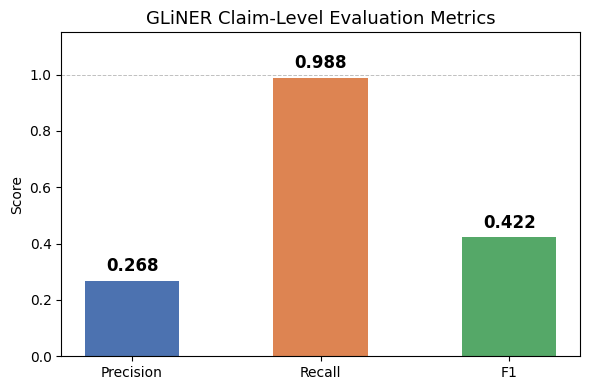

Saved: /Users/gloria/Desktop/Hiwi/visualizations/validation_visualizations/metrics_barplot_100.png


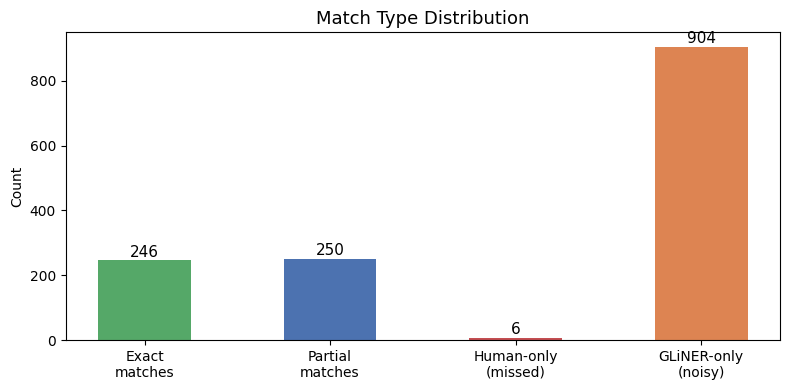

Saved: /Users/gloria/Desktop/Hiwi/visualizations/validation_visualizations/match_distribution_100.png


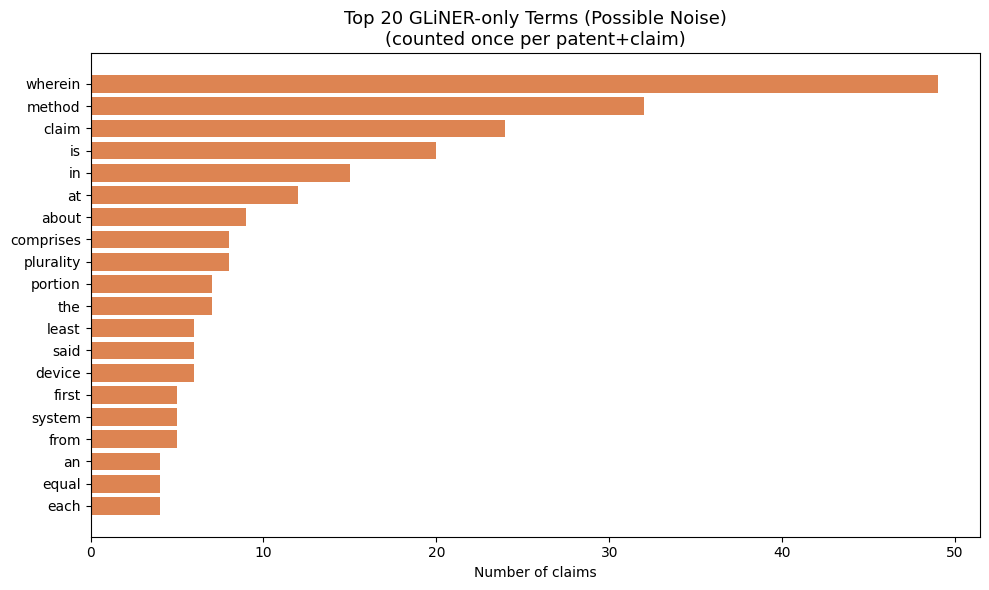

Saved: /Users/gloria/Desktop/Hiwi/visualizations/validation_visualizations/top_noisy_gliner_terms_100.png


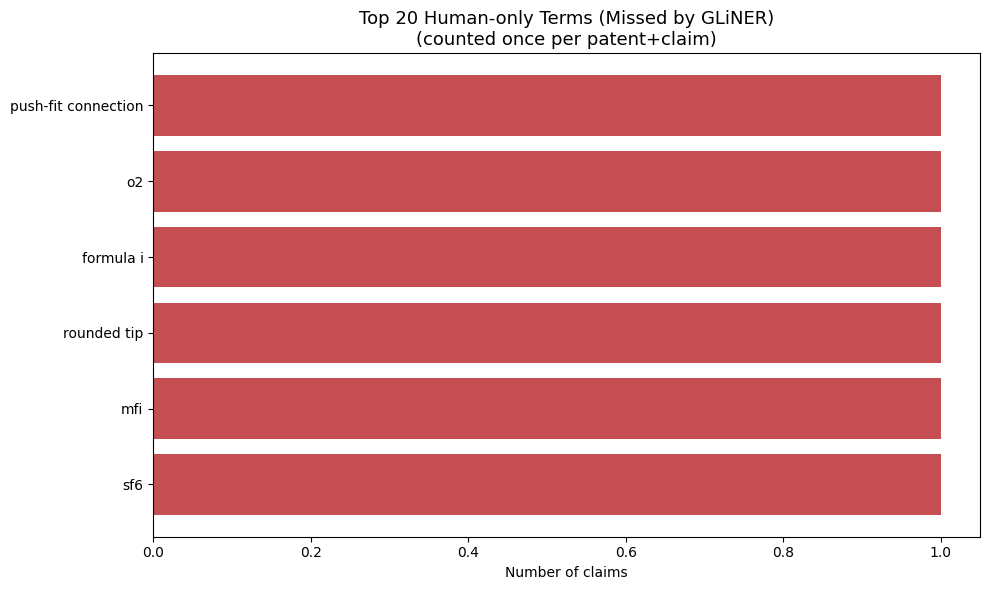

Saved: /Users/gloria/Desktop/Hiwi/visualizations/validation_visualizations/top_missed_human_terms_100.png


In [26]:
import polars as pl
import matplotlib.pyplot as plt
import os

eval_dir   = '/Users/gloria/Desktop/Hiwi/data/evaluation/'
viz_dir    = '/Users/gloria/Desktop/Hiwi/visualizations/validation_visualizations/'
output_dir = '/Users/gloria/Desktop/Hiwi/output/validation_outputs/'
os.makedirs(eval_dir, exist_ok=True)
os.makedirs(viz_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

# Recompute counts from eval_df so this cell is self-contained
n_exact_   = eval_df.filter(pl.col('match_type') == 'exact').height
n_partial_ = eval_df.filter(pl.col('match_type') == 'partial').height
n_matched_ = n_exact_ + n_partial_
n_human_   = human_long.height
n_gliner_  = gliner_norm.height
n_human_u  = human_only_df.height
n_gliner_u = gliner_only_df.height
precision_ = n_matched_ / n_gliner_  if n_gliner_  > 0 else 0.0
recall_    = n_matched_ / n_human_   if n_human_   > 0 else 0.0
f1_        = 2 * precision_ * recall_ / (precision_ + recall_) if (precision_ + recall_) > 0 else 0.0

# ── A. Precision / Recall / F1 bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
names  = ['Precision', 'Recall', 'F1']
vals   = [precision_, recall_, f1_]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars   = ax.bar(names, vals, color=colors, width=0.5)
ax.set_ylim(0, 1.15)
ax.set_title('GLiNER Claim-Level Evaluation Metrics', fontsize=13)
ax.set_ylabel('Score')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(viz_dir + 'metrics_barplot_100.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {viz_dir}metrics_barplot_100.png')

# ── B. Match type distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
labels_ = ['Exact\nmatches', 'Partial\nmatches', 'Human-only\n(missed)', 'GLiNER-only\n(noisy)']
counts_ = [n_exact_, n_partial_, n_human_u, n_gliner_u]
colors_ = ['#55A868', '#4C72B0', '#C44E52', '#DD8452']
bars    = ax.bar(labels_, counts_, color=colors_, width=0.5)
ax.set_title('Match Type Distribution', fontsize=13)
ax.set_ylabel('Count')
for bar, val in zip(bars, counts_):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(viz_dir + 'match_distribution_100.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {viz_dir}match_distribution_100.png')

# ── C. Top 20 noisy GLiNER terms (one count per patent+claim) ────────────────
# Deduplicate: each term counted at most once per (patent_id, claim_number)
top_noisy = (
    gliner_only_df
    .unique(subset=['patent_id', 'claim_number', 'gliner_term'])
    .group_by('gliner_term').len()
    .sort('len', descending=True).head(20)
)
top_noisy.write_csv(output_dir + 'top_noisy_gliner_terms_100.csv')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_noisy['gliner_term'].to_list()[::-1],
        top_noisy['len'].to_list()[::-1], color='#DD8452')
ax.set_xlabel('Number of claims')
ax.set_title('Top 20 GLiNER-only Terms (Possible Noise)\n(counted once per patent+claim)', fontsize=13)
plt.tight_layout()
plt.savefig(viz_dir + 'top_noisy_gliner_terms_100.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {viz_dir}top_noisy_gliner_terms_100.png')

# ── D. Top 20 missed human terms (one count per patent+claim) ────────────────
# Deduplicate: each term counted at most once per (patent_id, claim_number)
top_missed = (
    human_only_df
    .unique(subset=['patent_id', 'claim_number', 'human_term'])
    .group_by('human_term').len()
    .sort('len', descending=True).head(20)
)
top_missed.write_csv(output_dir + 'top_missed_human_terms_100.csv')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_missed['human_term'].to_list()[::-1],
        top_missed['len'].to_list()[::-1], color='#C44E52')
ax.set_xlabel('Number of claims')
ax.set_title('Top 20 Human-only Terms (Missed by GLiNER)\n(counted once per patent+claim)', fontsize=13)
plt.tight_layout()
plt.savefig(viz_dir + 'top_missed_human_terms_100.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {viz_dir}top_missed_human_terms_100.png')

In [27]:
import polars as pl

matched_df = eval_df.filter(pl.col('match_type').is_in(['exact', 'partial']))

print('═' * 65)
print('QUALITATIVE ANALYSIS')
print('═' * 65)

print('\n── Exact match + correct label (best extractions) ───────────')
for row in eval_df.filter(
    (pl.col('match_type') == 'exact') & (pl.col('label_match') == 'yes')
).head(8).to_dicts():
    print(f'  "{row["human_term"]}"  [{row["human_label"]}]')

print('\n── Exact term match but wrong label ──────────────────────────')
for row in eval_df.filter(
    (pl.col('match_type') == 'exact') & (pl.col('label_match') == 'no')
).head(6).to_dicts():
    print(f'  "{row["human_term"]}"  human=[{row["human_label"]}]  GLiNER=[{row["gliner_label"]}]')

print('\n── Partial overlaps (span / boundary issues) ─────────────────')
for row in eval_df.filter(pl.col('match_type') == 'partial').head(8).to_dicts():
    print(f'  Human: "{row["human_term"]}"  ←→  GLiNER: "{row["gliner_term"]}"')

print('\n── Noisy generic GLiNER terms (≤4 characters) ────────────────')
for row in gliner_only_df.filter(
    pl.col('gliner_term').str.len_chars() <= 4
).head(10).to_dicts():
    print(f'  "{row["gliner_term"]}"  [{row["gliner_label"]}]')

print('\n── Missed technical terms (human-only, not found by GLiNER) ──')
for row in human_only_df.to_dicts():
    print(f'  "{row["human_term"]}"  [{row["human_label"]}]')

print('\n── Most common label mismatches (human → GLiNER) ─────────────')
for row in (
    matched_df.filter(pl.col('label_match') == 'no')
    .group_by(['human_label', 'gliner_label']).len()
    .sort('len', descending=True).head(10)
).to_dicts():
    print(f'  {row["len"]}x  "{row["human_label"]}" → "{row["gliner_label"]}"')


═════════════════════════════════════════════════════════════════
QUALITATIVE ANALYSIS
═════════════════════════════════════════════════════════════════

── Exact match + correct label (best extractions) ───────────
  "bmp-4"  [Amino Acid, Peptide, or Protein]
  "bmp-6"  [Amino Acid, Peptide, or Protein]
  "amino acid"  [Amino Acid, Peptide, or Protein]
  "transgene"  [Gene or Genome]
  "coupler plug unit"  [Manufactured Object]
  "phenyl"  [Organic Chemical]
  "video"  [Intellectual Product]
  "4-butoxyphenyl"  [Organic Chemical]

── Exact term match but wrong label ──────────────────────────
  "weighting factor"  human=[Intellectual Product]  GLiNER=[Indicator, Reagent, or Diagnostic Aid]
  "pseudowire"  human=[Intellectual Product]  GLiNER=[Physical Object]
  "tautomer"  human=[Chemical Viewed Structurally]  GLiNER=[Inorganic Chemical]
  "4-fluorophenyl"  human=[Organic Chemical]  GLiNER=[Chemical]
  "1-propylbutyl"  human=[Organic Chemical]  GLiNER=[Chemical]
  "detergents"  human=

---
## 17. Interpretation

### Overview of results

| Metric | Value |
|---|---|
| Human terms | 502 |
| GLiNER terms (unique per claim) | 1 848 |
| Exact matches | 246 |
| Partial matches | 250 |
| Matched (exact + partial) | 496 |
| Unmatched human terms | 6 |
| Unmatched GLiNER terms | 904 |
| **Precision** | **0.27** |
| **Recall** | **0.99** |
| **F1** | **0.42** |
| Label accuracy (matched terms) | 0.34 |

---

### Finding 1 — Recall is near-perfect, precision is low

GLiNER identified 496 out of 502 human-annotated terms (recall = 0.99). Only 6 human terms were missed entirely — small chemical names and abbreviations (`sf6`, `o2`, `mfi`, `formula i`) or compound technical phrases (`rounded tip`, `push-fit connection`) that GLiNER does not extract.

However, GLiNER produced 1 848 terms per 100 claims, compared to 502 from humans — roughly **3.7× more**. Of those 1 848, only 496 overlapped with human annotations. The remaining **904 GLiNER terms had no human counterpart** (precision = 0.27).

### Finding 2 — Noise is dominated by patent legal boilerplate

The top GLiNER-only terms are structural patent language rather than technical content:

| Term | Claims | Note |
|---|---|---|
| `wherein` | 49 | Legal connector, not a concept |
| `method` | 32 | Structural patent word |
| `claim` | 24 | Self-referential patent language |
| `is`, `in`, `at` | 15–20 | Stop words |
| `plurality`, `comprises` | 8 | Patent boilerplate |

These terms account for a large share of GLiNER's false positives. A simple stop-word filter or minimum-length threshold (e.g., ≥3 characters, not in a patent boilerplate list) would substantially improve precision.

### Finding 3 — Half of matches are partial (span boundary issues)

246 terms matched exactly, while 250 matched only partially — meaning one term contained the other as a substring. This reflects a systematic span boundary problem: GLiNER often identifies the right concept but extracts an incomplete or over-extended span (e.g., `growth factor` instead of `platelet-derived growth factor`, or `carbonate` instead of `dimethyl carbonate`).

### Finding 4 — Label accuracy is low, but confusions are systematic and near-adjacent

Label accuracy among matched terms is 0.34 (169/496). The most frequent mismatches are:

| Human label | GLiNER label | Count | Nature |
|---|---|---|---|
| Organic Chemical | Chemical | 36 | Hierarchical — both correct in broader sense |
| Manufactured Object | Physical Object | 25 | Near-adjacent category |
| Gene or Genome | Immunologic Factor | 14 | Functional vs structural confusion |
| Manufactured Object | Medical Device | 11 | Contextual confusion |
| Body Part / Organ | Anatomical Structure | 5 | Hierarchical |

Importantly, **most mismatches are between semantically adjacent categories**, not random errors. The Organic Chemical ↔ Chemical confusion (36 cases) accounts for the largest share and is essentially a hierarchy disagreement rather than a substantive error.

### Interpretation for downstream use

- **GLiNER is suitable as a high-recall first-pass extractor.** It misses very few meaningful terms.
- **Post-processing noise filtering is essential.** Removing stop words, single characters, and patent boilerplate would reduce the 904 noisy terms significantly.
- **Label precision is limited.** For tasks requiring fine-grained semantic labelling, GLiNER labels should be treated as approximate semantic families, not precise ontology assignments.
- **This is not strict biomedical NER evaluation.** Labels are approximate semantic categories, and near-label matches (Chemical vs Organic Chemical) may be acceptable depending on the downstream analysis goal.